Notebook Author: Steven Camacho

The following notebook extracts from the FabSim code, the functions and code necessary to adapt it towards assessing fitness on an individual of the job-based representation, i.e (0,2,1,2,0,0,2,1,1) in the case of 3 unique jobs with 3 operations each. This notebook is organized in the following manner:


*   Imports
*   Dataframe copy function
*   Function for generating jobs, equipments and operations dataframes
*   Scheduler Class
*   Gantt Chart visualization function for individual
*   Test Section - all functions from above are tested and validated
*   Execution Section - material from test section is condensed for use in other setups such as GA DEAP setups




Imports

In [ ]:
import pandas as pd
import random
from typing import Tuple, Dict, Any, Union
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import multiprocessing
import copy
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys
import time
!pip install -r requirements.txt

Copy function - useful for snapshots of dataframe states

In [ ]:
def deepCopy(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create a deep copy of a given DataFrame.
    Deep copy is fully independent from the original DataFrame, to avoid having the
    copy of the dataframe share the same values as the original.
    Use case: for checkpoints when using processes that change dataframe.
    'take snapshots of the dataframe'
    """
    df_copy = pd.DataFrame(index=df.index, columns=df.columns)
    for col in df.columns:
        col_copy = []
        for val in df[col]:
            if isinstance(val, list):
                new_list = []
                for item in val:
                    new_list.append(item)
                col_copy.append(new_list)
            else:
                col_copy.append(copy.deepcopy(val))
        df_copy[col] = col_copy
    return df_copy

Function to generate job, equipment and operation dataframes

In [ ]:
def generate_orders(
    number_of_jobs: int,
    number_of_equipment: int,
    number_operation_types: int,
    min_operations: int,
    max_operations: int,
    min_duration: int,
    max_duration: int,
    last_arrival: int,
    equipments=None
):
    """
    Create matrices for jobs, equipments, and operations.
    These would be our "hard-coded" variables for our GA.
    Given problem paramteres relating to # of jobs, equipments, operation types,
    operations per job, duration time, and latest arrival time, dataframes for
    jobs, equipments, and operations are generated.
    The Jobs dataframe pertains to jobs and their details such as the operations they
    hold and what their type is, etc.
    The Equipments dataframe shows what each machine can do in terms of what operations it can process.
    The Operations dataframe only has the purpose of holding info regarding the specifics of the
    operation types, completely separate from the Jobs dataframe.
    The Jobs and Equipments dataframes also hold variables that relate to what is currently going on,
    specifically for this context of a model using reinforcement learning step by step, creating the
    schedule.

    Variables:
    - number_of_jobs: int -> number of jobs to generate
    - number_of_equipment: int -> number of equipment to generate
    - number_operation_types: int -> number of operation types to generate
    - min_operations: int -> minimum number of operations per job
    - max_operations: int -> maximum number of operations per job
    - min_duration: int -> minimum duration of an operation
    - max_duration: int -> maximum duration of an operation
    - last_arrival: int -> latest arrival time for a job
    - equipments: pd.DataFrame -> pre-generated equipment data (if available, not necessary)
    """
    random.seed(42)
    np.random.seed(42)
    # 1. Build or validate equipment table
    # Only if there isnt currently an equipments dataframe
    if equipments is None:

        # If there are more operation types than equipment types, we cannot proceed
        if number_of_equipment < number_operation_types:
            print(f"❌ Too few equipment: {number_of_equipment} < number of operation types: {number_operation_types}")
            sys.exit(1)

        # else continue, we now either have a perfect match or more equipment types (both valid)

        # equipment types will be the range of operation types, i.e. 0, 1
        equipment_op_types = list(range(number_operation_types))

        # check for extra equipment
        extra_equipment = number_of_equipment - number_operation_types
        if extra_equipment > 0:
            equipment_op_types += random.choices(range(number_operation_types), k=extra_equipment) # add k operation type equipment
        random.shuffle(equipment_op_types)

        # Now we would have an array in which the index represents the equipment, and the value would
        # represent what operation type it can process
        # Example for 5 equipments and 3 operation types: equipment_op_types = [1, 0, 0, 2, 1]

        # equipment records will hold each record per equipment
        equipment_records = []


        for eq_id in range(number_of_equipment):
            eq_op = equipment_op_types[eq_id] # get the equipment's operation type

            # create and populate a dictionary to hold equipment records and append to initially declared list
            equipment_records.append({
                "equipment_id": eq_id, # equipment identification
                "operation_id": eq_op, # what operation it can process
                "time": 0.0, # time
                "idle_time_between_jobs": 0.0, # idle time
                "jobs_assigned": [], # jobs assigned
                "assignment_starts": [], # assignment start time
                "assignment_ends": [], # assignment end time
            })

        # create dataframe
        equipments = pd.DataFrame(equipment_records)

        # sort dataframe by equipment identification
        equipments.sort_values(by="equipment_id", inplace=True, ignore_index=True)

    # if we are given an equipments dataframe, we just produce a deep copy and assign it to the dataframe for this function]\;
    else:
        equipments = deepCopy(equipments)

    # 2. Build op_type → equipment map
    # This line creates a dictionary of key: operation type -> value: ids of equipment that process that type of operation
    op_type_to_equip = equipments.groupby("operation_id")["equipment_id"].apply(set).to_dict()

    # Grab the operation types that are supported, i.e. have an equipment that can process it
    supported_op_types = set(op_type_to_equip.keys())

    # 3. Build jobs
    # Create list that will then hold records per job
    jobs_data = []

    # Iterate through each job and fill jobs_data
    for job_id in range(number_of_jobs):
        arrival_t = float(random.randint(0, int(last_arrival))) # Randomly assign arrival time by picking float between 0 and last_arrival variable
        num_ops = random.randint(min_operations, max_operations) # Randomly pick number of operations for job
        ops_seq = random.choices(list(supported_op_types), k=num_ops) # randomly pick the operations that the job will have from the supported op types (create operation sequence)
        dur_seq = [random.randint(min_duration, max_duration) for _ in range(num_ops)] # randomly pick duration for each operation

        # assign dictionary of records for job
        jobs_data.append({
            "job_id": job_id, # job identification
            "arrival_time": arrival_t, # arrival time for job
            "time": arrival_t, # time is also the arrival time
            "operation_time": 0.0, # operation time
            "queue_time": 0.0, # queue time
            "operations": ops_seq, # operations for the job
            "durations": dur_seq, # durations for each operation
            "completed_equipments": [], # completed equipments
            "completed_operations": [], # completed operations
            "assignment_starts": [], # assignment starts
            "assignment_ends": [], # assignment ends
        })

    # make data into dataframe
    jobs = pd.DataFrame(jobs_data)

    # sort by arrival time
    jobs.sort_values(by="arrival_time", inplace=True, ignore_index=True)

    # 4. Build operations table (op_type → equipment mapping)
    # grab operation id and equipment id and reset index to create an index column
    operations = equipments.reset_index()[["operation_id", "equipment_id"]]
    # set operation id as the index, very simple 2 column dataframe
    operations.set_index("operation_id", inplace=True)

    # return the three created dataframes
    return jobs, equipments, operations

Scheduler Class

In [ ]:
class Scheduler:
  """
  Scheduler class, created for each individual as it assesses the effectiveness of the proposed
  schedule sequence.
  """

  def __init__(
        self,
        jobs: pd.DataFrame,
        equipments: pd.DataFrame,
        operations: pd.DataFrame,
        num_jobs: int,
        num_equipment: int,
        num_operation_types: int,
        min_operations: int,
        max_operations: int,
        min_duration: int,
        max_duration: int,
        last_arrival: int,
        max_sim_time: int
  ):

    """
    Scheduler class constructor function. It is supposed to take in 3 blank jobs, equipments and operations dataframes
    (consistent randomness for each dataframe, i.e job, operation duration, operation type to equipment assignment),
    additionally takes in all other job, operation, equipment related details (i.e number of jobs, number of operation types)

    Input:
    - jobs: pd.DataFrame -> jobs dataframe
    - equipments: pd.DataFrame -> equipments dataframe
    - operations: pd.DataFrame -> operations dataframe
    - number_of_jobs: int -> number of jobs to generate
    - number_of_equipment: int -> number of equipment to generate
    - number_operation_types: int -> number of operation types to generate
    - min_operations: int -> minimum number of operations per job
    - max_operations: int -> maximum number of operations per job
    - min_duration: int -> minimum duration of an operation
    - max_duration: int -> maximum duration of an operation
    - last_arrival: int -> latest arrival time for a job

    Output:
    - creates sheduler object
    """
    self.jobs = jobs
    self.equipments = equipments
    self.operations = operations
    self.num_jobs = num_jobs
    self.num_equipment = num_equipment
    self.num_operation_types = num_operation_types
    self.min_operations = min_operations
    self.max_operations = max_operations
    self.min_duration = min_duration
    self.max_duration = max_duration
    self.last_arrival = last_arrival
    self.max_sim_time = max_sim_time
    self.total_duration = -1
    self.remaining_total_duration = -1
    self.unfinished_operations = 0

  def prepare_scheduler(self):
    """
    Scheduler initiation helper function. It will add variables necessary for future computation of schedule effectiveness.

    Input:
    - access to the scheduler object previously created

    Output:
    - variables added to the scheduler object:
      - wip_job_ids = work in progress job ids
      - job_ops_list = list of operations for each job (immutable)
      - job_durations_list = list of durations for each job (immutable)
      - job_current_op_index = current operation index for each job
      - done = flag variable for when schedule is done being assessed
      - last_time = the time clocked for the last operation on the schedule,
        added up from previous schedule operations, should be equivalent to makespan
      - op_to_equip = dictionary of operation to equipment mapping (immutable)
      - job_index_map =
      - equip_index_map =
      - unfinished_operations = starts off with operation quantity length of each job, gets reduced as operations are completed
      - total_operations = total number of operations (immutable)
      - total_duration = length of operations added up to represent total duration of the job (immutable)
      - remaining_total_duration = length of duration of job with subtractions being done for each operation that is completed
      - available_time =
    """

    self.wip_job_ids = set(self.jobs.index)
    self.job_ops_list = [row["operations"][:] for _, row in self.jobs.iterrows()]
    self.job_durations_list = [row["durations"][:]  for _, row in self.jobs.iterrows()]
    self.job_current_op_index = [0]*self.num_jobs
    self.done = False
    self.last_time = 0.0

    # Precompute operation -> [equipment IDs] (no repeated DataFrame calls)
    self.op_to_equip = {}
    for new_eq_idx, row in self.equipments.iterrows():
      op_id = row["operation_id"]
      if op_id not in self.op_to_equip:
          self.op_to_equip[op_id] = []
      self.op_to_equip[op_id].append(new_eq_idx)

    self.job_index_map   = {job_id: i for i, job_id in enumerate(self.jobs.index)}
    self.equip_index_map = {eq_id:  j for j, eq_id in enumerate(self.equipments.index)}

    self.unfinished_operations = self.jobs["operations"].apply(len).sum()
    self.total_operations = self.unfinished_operations
    self.total_duration = self.jobs["durations"].apply(sum).sum()
    self.remaining_total_duration = self.total_duration
    self.available_time = 0.0

  def find_matching_equipment(self, job_id: int)->int:
    """
    Function to find matching equipment for job
    So far, no optimization for when machine is available,
    main purpose of function is just find a match in terms of
    equipment that can complete the operation from the job

    Input:
    - access to the scheduler object previously created
    - job_id = job id in question at current point in individual sequence

    Output:
    - equip_id = matching equipment id that can process whatever needed operation type from job
    """
    print("#################FINDING MATCHING EQUIPMENT###################")
    attempts = 0

    # get total jobs in progress
    total = len(self.wip_job_ids)
    print("# total jobs in progress:\n")
    print(total)

    # get the current operation up next from job
    op_idx = self.job_current_op_index[job_id]
    print("# current operation index:\n")
    print(op_idx)

    # if operation index from job is less than the length of operations from a job, proceed
    if op_idx < len(self.job_ops_list[job_id]):
        print("# operation index from job is less than the length of operations from a job")
        # get the operation type of the operation that is up next
        needed_op = self.job_ops_list[job_id][op_idx]
        print("## operation type:\n")
        print(needed_op)
    else:
        print("# operation index from job is greater than the length of operations from a job, job is done")
        # job is actually done
        self.wip_job_ids.remove(job_id)

        # if no work in progress jobs left, return None
        print("## quantity of jobs still work in progress\n")
        print(len(self.wip_job_ids))
        if len(self.wip_job_ids) == 0:
            return None

    # extra check if the operation index surpasses the length of operations from
    # a job and there is still work in progress left, return None
    if op_idx >= len(self.job_ops_list[job_id]):
      print("# operation index surpasses the length of operations from a job and there is still work in progress left, return None")
      return None

    # from the operations table, grab the rows that correspond to the operation type specified
    valid_ops_rows = self.operations.loc[[needed_op]]
    print("# valid operations rows from operations table:\n")
    print(valid_ops_rows)

    # find possible equipment that can do needed_op
    candidate_equip_ids = [
      eid for eid in valid_ops_rows["equipment_id"].tolist()
        if eid in self.equipments.index
    ]
    print("# candidate equipment ids from the valid operation rows:\n")
    print(candidate_equip_ids)

    # if no equipment id found to be able to do operation, return None
    if not candidate_equip_ids:
      print("# no equipment id found to be able to do operation, return None")
      return None

    # This is the part that would be optimized if we were to incorporate some sort of search to take advantage of idle time
    # for now, pick random equipment from candidate list
    # CHANGE TO PICK MACHINE WITH THE EARLIEST END TIME FOR CURRENT/LAST OPERATION
    equip_id = random.choice(candidate_equip_ids)
    print("# chosen equipment id:\n")
    print(equip_id)
    print("################################################################")
    return equip_id

  def step(
          self,
          job_id: int,
  ) -> int:
    """
    step function represents our fitness assessment method for an individual. This function will be iteratively called
    on each gene from the individual, i.e each job id found in the job-based sequence.


    Input:
    - access to the scheduler object previously created
    - job_id = job id in question at current point in individual sequence

    Output:
    - self.available_time = makespan calculation at current point in individual sequence
    """
    print("#################STEP###################")
    print("# job id:\n")
    print(job_id)

    equip_id = self.find_matching_equipment(job_id)
    print("# equipment id:\n")
    print(equip_id)
      # define info dictionary that will account for validity in the following:
      # - is the job id in range?
      # - is the equipment id in range?
      # - any empty operations?
      # - operation match?
      # - truncated? as in the schedule becomes invalid.
    info = {
        "check_job_id_in_range": False,
        "check_equipment_id_in_range": False,
        "check_not_empty_operations": False,
        "check_operations_match": False,
        "truncated": False
      }

    # Initial validation checks
    failed_checks = 0

    # is the given job id a valid id?
    if job_id not in self.jobs.index:
        print("# job id not in range")
        failed_checks += 1

    # is the given equipment id a valid id?
    if equip_id not in self.equipments.index:
        print("# equipment id not in range")
        failed_checks += 1

    # something is not valid, cancel entire process
    if failed_checks > 0:
        print("# something is not valid from initial validation checks")
        self.done = True
        truncated = True
        info["truncated"] = True

        # adjust what is returned
        return self.done, truncated, info

    # Get job and equipment references from dataframes
    job_row = self.jobs.loc[job_id] # get job row
    print("# job row:\n")
    print(job_row)

    eq_row = self.equipments.loc[equip_id] # get equipment row
    print("# equipment row:\n")
    print(eq_row)

    # get the current operation from the job (at the start that will be 0)
    op_idx = self.job_current_op_index[job_id]
    print("# current operation index:\n")
    print(op_idx)

    # Operation validation
    # check if the index of the operation is out of bounds from the operation array from the job
    if op_idx >= len(self.job_ops_list[job_id]):
        failed_checks += 1
        print("# operation index is out of bounds from the operation array from the job")
    else:
      # get operation type
      needed_op = self.job_ops_list[job_id][op_idx]
      print("# operation type:\n")
      print(needed_op)

    # if operation type does not match the equipment type, fail
    if eq_row["operation_id"] != needed_op:
        print("# operation type does not match the equipment type")
        failed_checks += 1

    # something is not valid from operation validation
    if failed_checks > 0:
        print("# something is not valid from operation validation")
        self.done = True
        truncated = True
        info["truncated"] = True
        return self.done, truncated, info

    # Scheduling logic
    job_old_time = job_row["time"] # grab the old time of the job (time when whatever operation from job happened beforehand ends)
    print("# when jobs current or past operations ends/ended:\n")
    print(job_old_time)

    print("# when equipment is next available:\n")
    print(eq_row["time"])

    scheduled_time = max(job_row["time"], eq_row["time"]) # pick the larger of times between job and equipment
    print("# longer time between the two (will be starting time for current operation):\n")
    print(scheduled_time)

    current_duration = self.job_durations_list[job_id][op_idx] # grab the duration of the operation from the job
    print("# current operation duration:\n")
    print(current_duration)

    self.available_time = scheduled_time + current_duration # available time is the larger of times between job and equipment + the duration of the operation
    print("# when operation can be started + duration = end time of job at this current point:\n")
    print(self.available_time)

    # Calculate time deltas
    last_time_available_delta = self.last_time - self.available_time # subtract from last time

    # Update global time tracking
    self.last_time = max(self.available_time, self.last_time)

    # Update the dataframes for future calculations
    # Initialize time deltas
    wait_delta = 0.0
    idle_delta = 0.0

    # Calculate time intervals
    if job_row["time"] < scheduled_time:
        wait_delta = scheduled_time - job_row["time"]
        self.jobs.at[job_id, "queue_time"] = job_row["queue_time"] + wait_delta

    if eq_row["time"] > 0 and eq_row["time"] < scheduled_time:
        idle_delta = scheduled_time - eq_row["time"]
        self.equipments.at[equip_id, "idle_time_between_jobs"] += idle_delta

    # Update job and equipment states
    self.remaining_total_duration -= current_duration
    self.jobs.at[job_id, "operation_time"] += current_duration

    # update job time (when current operation of job finishes, aka can proceed in job operation array)
    self.jobs.at[job_id, "time"] = self.available_time
    print("# new time for when job will be able to pass its next operation:\n")
    print(self.jobs.at[job_id, "time"])

    # update equipment time (when equipment is next available)
    self.equipments.at[equip_id, "time"] = self.available_time
    print("# new time for when equipment will be available:\n")
    print(self.equipments.at[equip_id, "time"])

    # Record assignment history
    self.jobs.at[job_id, "assignment_starts"].append(scheduled_time)
    self.jobs.at[job_id, "assignment_ends"].append(self.available_time)
    self.equipments.at[equip_id, "assignment_starts"].append(scheduled_time)
    self.equipments.at[equip_id, "assignment_ends"].append(self.available_time)

    # add job to equipment record
    self.equipments.at[equip_id, "jobs_assigned"].append(job_id)

    # Track completed operations
    self.jobs.at[job_id, "completed_operations"].append(needed_op)
    self.jobs.at[job_id, "completed_equipments"].append(equip_id)

    # decrease num of unfinished operations by 1
    self.unfinished_operations -= 1

    # Advance operation pointer
    self.job_current_op_index[job_id] += 1
    print("# new current operation index:\n")
    print(self.job_current_op_index[job_id])

    # check if job is now finished
    if self.job_current_op_index[job_id] >= len(self.job_ops_list[job_id]):
        print("# job is now finished")
        # job is actually done
        self.wip_job_ids.remove(job_id)

    # process successful, schedule still valid
    truncated = False

    # update expected finish time
    eta_finish_time = (self.last_time + self.remaining_total_duration)

    print(f"# time of job {job_id} so far:\n")
    print(self.available_time)

    print("####################################################")
    # return available time
    return self.available_time


Gantt Chart function - visualize schedule

In [ ]:
def plot_gantt_chart(equipments: pd.DataFrame):
    """
    Creates a Gantt chart based on the equipments DataFrame.
    """
    unique_jobs = set()
    for _, row in equipments.iterrows():
        jobs_assigned = row.get("jobs_assigned", [])
        if isinstance(jobs_assigned, list):
            unique_jobs.update(jobs_assigned)
    unique_jobs = sorted(unique_jobs)

    cmap = mpl.cm.get_cmap('tab20', len(unique_jobs))
    job_colors = {job: cmap(i) for i, job in enumerate(unique_jobs)}

    max_end_time = 0
    for _, row in equipments.iterrows():
        ends = row.get("assignment_ends", [])
        if isinstance(ends, list) and len(ends) > 0:
            max_end_time = max(max_end_time, max(ends))

    plt.figure(figsize=(12, 8))
    for equip_id, row in equipments.iterrows():
        jobs_assigned = row.get("jobs_assigned", [])
        starts = row.get("assignment_starts", [])
        ends = row.get("assignment_ends", [])
        if not (isinstance(jobs_assigned, list) and len(jobs_assigned) > 0):
            continue
        for job, start, end in zip(jobs_assigned, starts, ends):
            duration = end - start
            color = job_colors.get(job, 'gray')
            plt.barh(
                y=equip_id, width=duration, left=start, height=0.4,
                align='center', color=color, alpha=0.8, edgecolor='black'
            )
            plt.text(
                x=start + duration/2, y=equip_id,
                s=str(job), va='center', ha='center', color='white', fontsize=8
            )

    sorted_equips = sorted(equipments.index)
    for eq in sorted_equips:
        plt.axhline(y=eq + 0.5, color='black', linestyle='-', linewidth=1)
        plt.axhline(y=eq - 0.5, color='black', linestyle='-', linewidth=1)

    plt.xlabel("Time")
    plt.ylabel("Equipment ID")
    plt.title("Gantt Chart of Equipment Assignments")
    plt.xlim(0, max_end_time + 5)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Test Section

In [ ]:
# ---------------------------
# Constants
# ---------------------------

NUM_JOBS         = 3
NUM_EQUIPMENT    = 3
NUM_OP_TYPES     = 3
MIN_OPERATIONS   = 3
MAX_OPERATIONS   = 3
MIN_DURATION     = 1
MAX_DURATION     = 4
LAST_ARRIVAL     = 0

MAX_SIM_TIME = NUM_JOBS * MAX_OPERATIONS * MAX_DURATION

In [ ]:
# Call Generate orders function
jobs, equipment, operations = generate_orders(NUM_JOBS, NUM_EQUIPMENT, NUM_OP_TYPES, MIN_OPERATIONS, MAX_OPERATIONS, MIN_DURATION, MAX_DURATION, LAST_ARRIVAL)

In [ ]:
# construct scheduler
scheduler = Scheduler(jobs, equipment, operations, NUM_JOBS, NUM_EQUIPMENT, NUM_OP_TYPES, MIN_OPERATIONS, MAX_OPERATIONS, MIN_DURATION, MAX_DURATION, LAST_ARRIVAL, MAX_SIM_TIME)

In [ ]:
# Check scheduler variables
print("#####jobs dataframe#####\n")
print(scheduler.jobs)
print("\n#####equipments dataframe#####\n")
print(scheduler.equipments)
print("\n#####operations dataframe#####\n")
print(scheduler.operations)
print("\n")
print("number of jobs: ", scheduler.num_jobs)
print("number of equipment: ", scheduler.num_equipment)
print("number of operation types: ", scheduler.num_operation_types)
print("min operations: ", scheduler.min_operations)
print("max operations: ", scheduler.max_operations)
print("min duration: ", scheduler.min_duration)
print("max duration: ", scheduler.max_duration)
print("last arrival: ", scheduler.last_arrival)
print("total duration: ", scheduler.total_duration)
print("remaining total duration: ", scheduler.remaining_total_duration)
print("unfinished operations: ", scheduler.unfinished_operations)

#####jobs dataframe#####

   job_id  arrival_time  time  operation_time  queue_time operations  \
0       0           0.0   0.0             0.0         0.0  [0, 0, 0]   
1       1           0.0   0.0             0.0         0.0  [0, 1, 0]   
2       2           0.0   0.0             0.0         0.0  [2, 0, 2]   

   durations completed_equipments completed_operations assignment_starts  \
0  [1, 4, 1]                   []                   []                []   
1  [2, 4, 2]                   []                   []                []   
2  [4, 3, 3]                   []                   []                []   

  assignment_ends  
0              []  
1              []  
2              []  

#####equipments dataframe#####

   equipment_id  operation_id  time  idle_time_between_jobs jobs_assigned  \
0             0             1   0.0                     0.0            []   
1             1             0   0.0                     0.0            []   
2             2             2   0.0 

In [ ]:
# Additional variables initialized for scheduler
scheduler.prepare_scheduler()

In [ ]:
# individual created to represent three distinct jobs each with three operations
individual = [0, 1, 1, 2, 2, 0, 1, 0, 2]
print(len(individual))

9


In [ ]:
original_jobs = deepCopy(scheduler.jobs)
original_equipments = deepCopy(scheduler.equipments)
original_operations = deepCopy(scheduler.operations)
job_dfs = []
job_dfs.append(original_jobs)
equip_dfs = []
equip_dfs.append(original_equipments)
operation_dfs = []
operation_dfs.append(original_operations)

In [ ]:
print("Individual: ", individual)
print("\n")
for j in individual:
  scheduler.step(j)
  job_dfs.append(deepCopy(scheduler.jobs))
  equip_dfs.append(deepCopy(scheduler.equipments))
  operation_dfs.append(deepCopy(scheduler.operations))

print("makespan:",  scheduler.jobs['time'].max())

Individual:  [0, 1, 1, 2, 2, 0, 1, 0, 2]


#################STEP###################
# job id:

0
#################FINDING MATCHING EQUIPMENT###################
# total jobs in progress:

3
# current operation index:

0
# operation index from job is less than the length of operations from a job
## operation type:

0
# valid operations rows from operations table:

              equipment_id
operation_id              
0                        1
# candidate equipment ids from the valid operation rows:

[1]
# chosen equipment id:

1
################################################################
# equipment id:

1
# job row:

job_id                          0
arrival_time                  0.0
time                          0.0
operation_time                0.0
queue_time                    0.0
operations              [0, 0, 0]
durations               [1, 4, 1]
completed_equipments           []
completed_operations           []
assignment_starts              []
assignment_ends               

In [ ]:
# Check the state of the dataframes
print("#####jobs dataframe#####\n")
print(scheduler.jobs)
print("\n#####equipments dataframe#####\n")
print(scheduler.equipments)
print("\n#####operations dataframe#####\n")
print(scheduler.operations)
print("\n")

#####jobs dataframe#####

   job_id  arrival_time  time  operation_time  queue_time operations  \
0       0           0.0  14.0             6.0         8.0  [0, 0, 0]   
1       1           0.0  13.0             8.0         5.0  [0, 1, 0]   
2       2           0.0  10.0            10.0         0.0  [2, 0, 2]   

   durations completed_equipments completed_operations assignment_starts  \
0  [1, 4, 1]            [1, 1, 1]            [0, 0, 0]  [0.0, 7.0, 13.0]   
1  [2, 4, 2]            [1, 0, 1]            [0, 1, 0]  [1.0, 3.0, 11.0]   
2  [4, 3, 3]            [2, 1, 2]            [2, 0, 2]   [0.0, 4.0, 7.0]   

     assignment_ends  
0  [1.0, 11.0, 14.0]  
1   [3.0, 7.0, 13.0]  
2   [4.0, 7.0, 10.0]  

#####equipments dataframe#####

   equipment_id  operation_id  time  idle_time_between_jobs  \
0             0             1   7.0                     0.0   
1             1             0  14.0                     1.0   
2             2             2  10.0                     3.0   

  

/tmp/ipython-input-3989361025.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('tab20', len(unique_jobs))


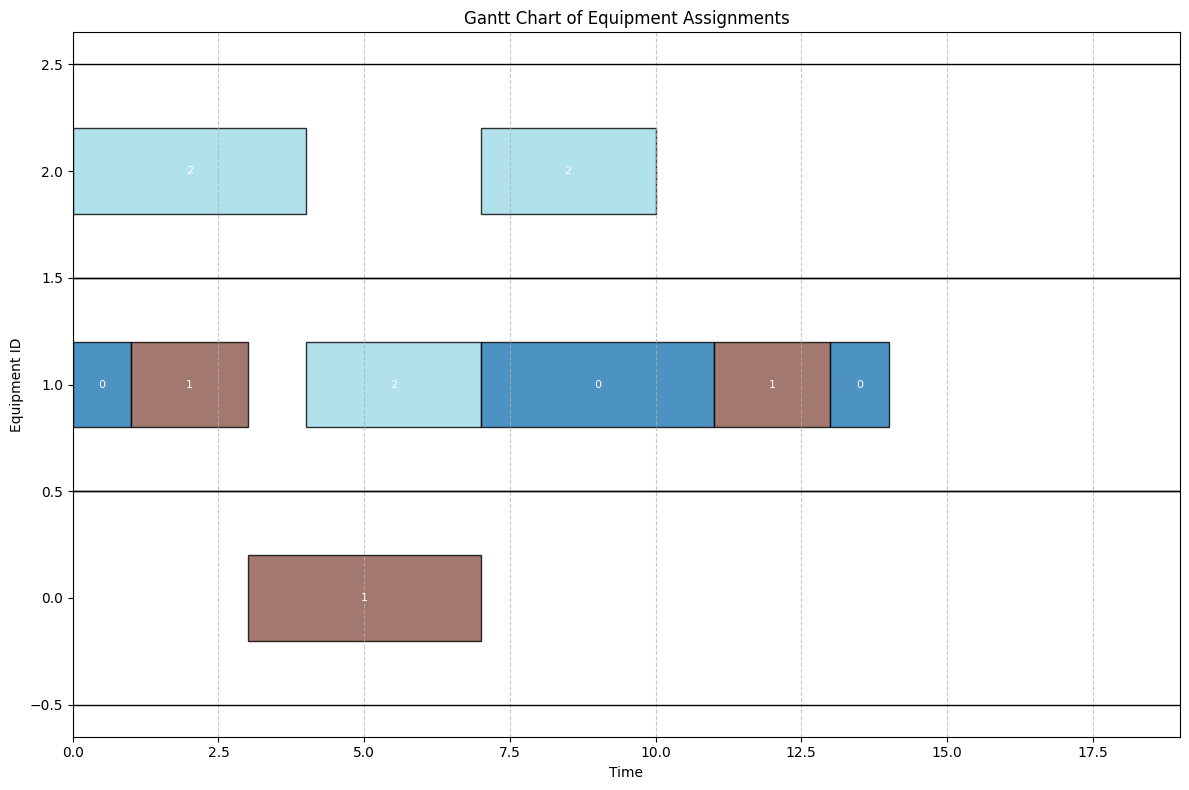

In [ ]:
# Visualize Schedule
plot_gantt_chart(scheduler.equipments)

Execution section - section in which everything from test section is condensed for future use in genetic algorithm setups

In [ ]:
# fitness function representation
def fitness_wrapper(individual, NUM_JOBS, NUM_EQUIPMENT, NUM_OP_TYPES, MIN_OPERATIONS, MAX_OPERATIONS, MIN_DURATION, MAX_DURATION, LAST_ARRIVAL, MAX_SIM_TIME):
  jobs, equipment, operations = generate_orders(NUM_JOBS, NUM_EQUIPMENT, NUM_OP_TYPES, MIN_OPERATIONS, MAX_OPERATIONS, MIN_DURATION, MAX_DURATION, LAST_ARRIVAL)
  scheduler = Scheduler(jobs, equipment, operations, NUM_JOBS, NUM_EQUIPMENT, NUM_OP_TYPES, MIN_OPERATIONS, MAX_OPERATIONS, MIN_DURATION, MAX_DURATION, LAST_ARRIVAL, MAX_SIM_TIME)
  scheduler.prepare_scheduler()
  for j in individual:
    scheduler.step(j)
  plot_gantt_chart(scheduler.equipments)
  makespan = scheduler.available_time
  return makespan


In [ ]:
# function used to generate an individual given k jobs and n operations per job
def gen_individual(k, n):
  np.random.seed(None)
  arr = np.repeat(np.arange(k), n)
  np.random.shuffle(arr)
  return arr.tolist()


In [ ]:
# ---------------------------
# Constants
# ---------------------------

NUM_JOBS         = 4
NUM_EQUIPMENT    = 4
NUM_OP_TYPES     = 4
MIN_OPERATIONS   = 4
MAX_OPERATIONS   = 4
MIN_DURATION     = 1
MAX_DURATION     = 4
LAST_ARRIVAL     = 0

# Keep MAX_SIM_TIME for scenario logic or upper-bound checks,
# but we will no longer store a length-of-max_sim_time array in the observation.
MAX_SIM_TIME = NUM_JOBS * MAX_OPERATIONS * MAX_DURATION

[1, 3, 0, 0, 2, 3, 2, 0, 2, 1, 3, 0, 2, 3, 1, 1]


/tmp/ipython-input-3989361025.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('tab20', len(unique_jobs))


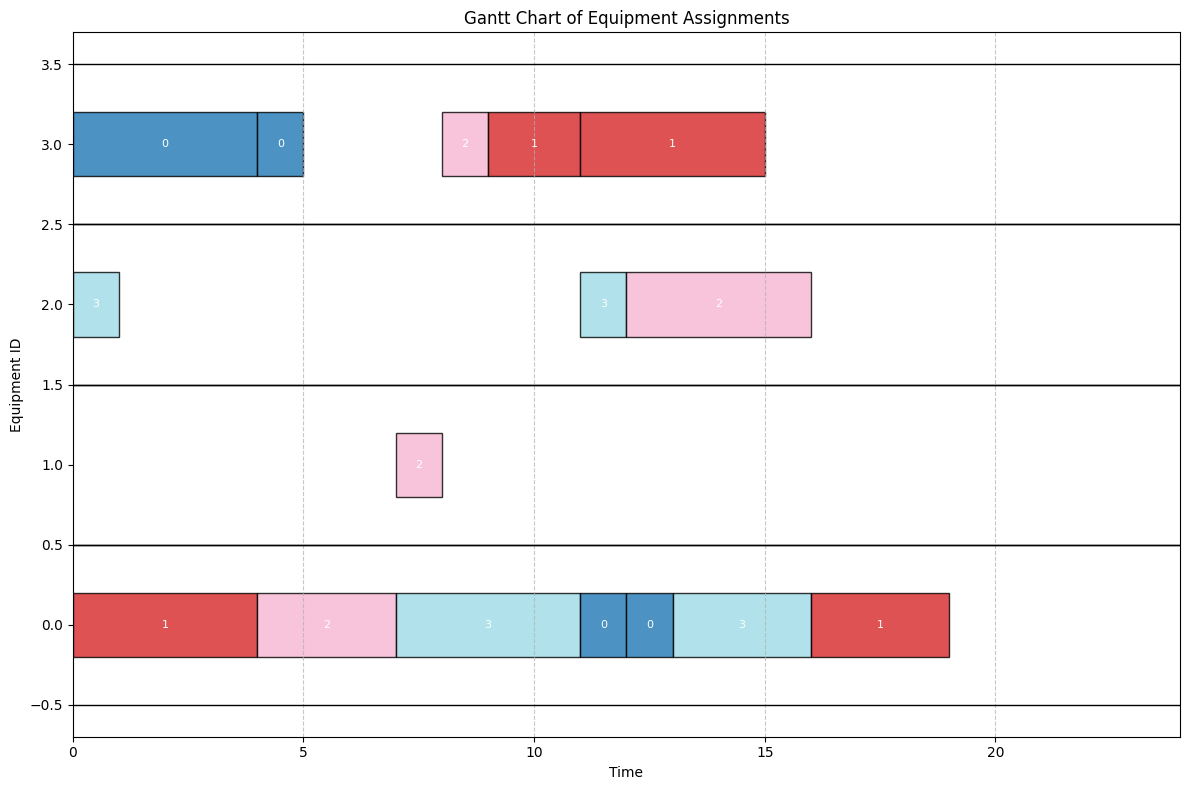

19.0

In [ ]:
# test individual and fitness functions
individual = gen_individual(NUM_JOBS, NUM_OP_TYPES)
print("Individual: ", individual)
fitness_wrapper(individual, NUM_JOBS, NUM_EQUIPMENT, NUM_OP_TYPES, MIN_OPERATIONS, MAX_OPERATIONS, MIN_DURATION, MAX_DURATION, LAST_ARRIVAL, MAX_SIM_TIME)